In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("heart_disease.xlsx", sheet_name="Heart_disease")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [4]:
df.describe

<bound method NDFrame.describe of      age   sex               cp  trestbps  chol    fbs           restecg  \
0     63  Male   typical angina       145   233   True    lv hypertrophy   
1     41  Male  atypical angina       135   203  False            normal   
2     57  Male     asymptomatic       140   192  False            normal   
3     52  Male   typical angina       118   186  False    lv hypertrophy   
4     57  Male     asymptomatic       110   201  False            normal   
..   ...   ...              ...       ...   ...    ...               ...   
903   53  Male     asymptomatic       125     0  False            normal   
904   62  Male     asymptomatic       166   170  False  st-t abnormality   
905   56  Male      non-anginal       170     0  False    lv hypertrophy   
906   56  Male      non-anginal       144   208   True  st-t abnormality   
907   57  Male     asymptomatic       142   277   True  st-t abnormality   

     thalch  exang  oldpeak        slope             

In [5]:
df['target'] = (df['num'] > 0).astype(int)

In [6]:
df = df.drop('num', axis=1)

In [7]:
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
target       0
dtype: int64

In [8]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
df['oldpeak'] = imputer.fit_transform(df[['oldpeak']])

In [9]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower, upper)

for col in numerical_cols:
    cap_outliers(df, col)

In [17]:
df['fbs'] = df['fbs'].astype(str)
df['exang'] = df['exang'].astype(str)

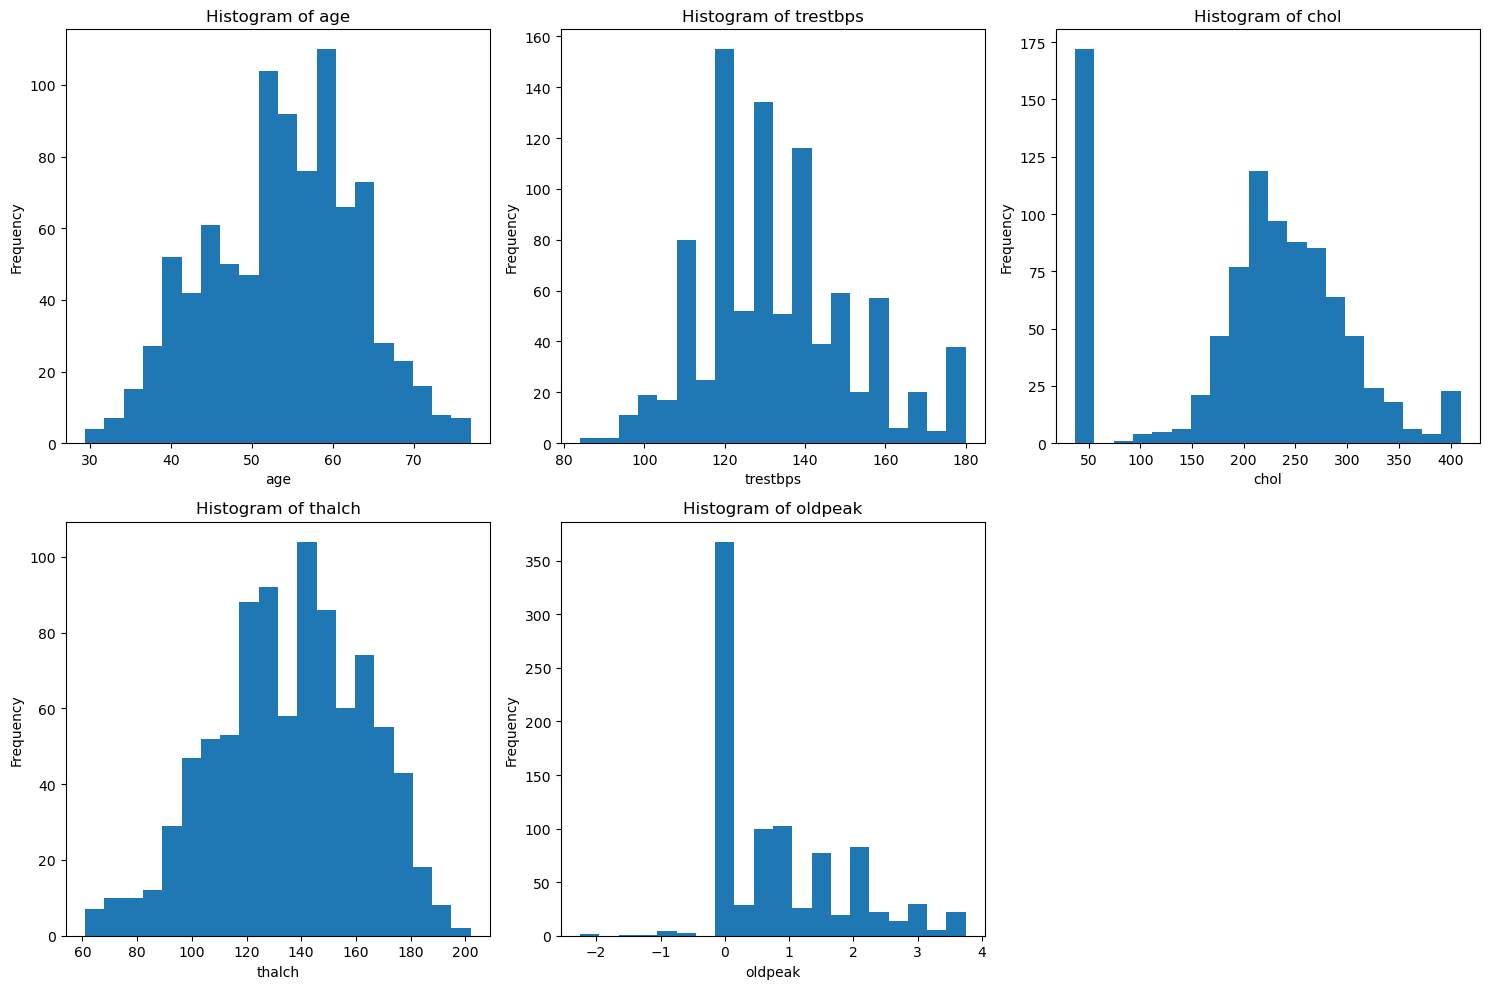

In [32]:
plt.figure(figsize=(15,10))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    plt.hist(df[col], bins=20)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

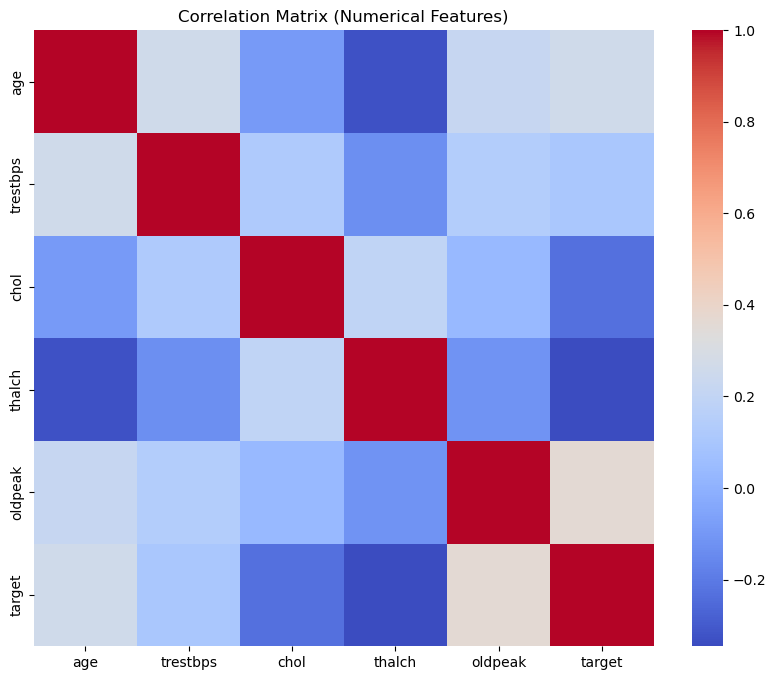

In [18]:
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=['int64','float64'])
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix (Numerical Features)")
plt.show()

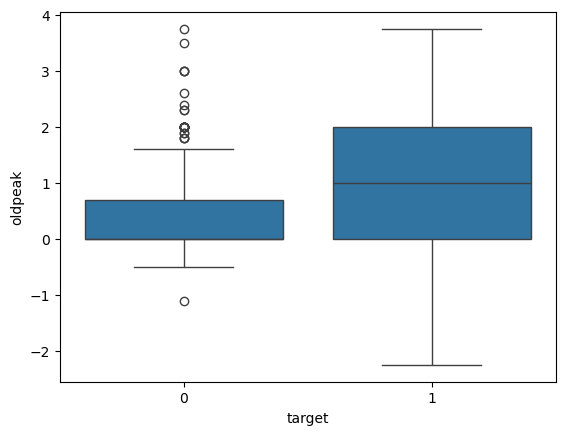

In [19]:
sns.boxplot(x='target', y='oldpeak', data=df)
plt.show()

In [20]:
X = df.drop('target', axis=1)
y = df['target']

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

dt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object'))])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [24]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = dt_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.7472527472527473
              precision    recall  f1-score   support

           0       0.72      0.69      0.71        80
           1       0.76      0.79      0.78       102

    accuracy                           0.75       182
   macro avg       0.74      0.74      0.74       182
weighted avg       0.75      0.75      0.75       182



In [30]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__max_depth': [4, 5, 6, 8],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_features': [None, 'sqrt', 'log2']
}

grid_search = GridSearchCV(
    dt_pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',   # 🔴 KEY CHANGE
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         'passthrough',
                                                                         Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak'], dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object'))])),
                                       ('classifier',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__criterion': ['gini', 'entropy'],
                         'classifier__max_depth': [4, 5, 6, 8],
                         'classifier__max_features': [None, 'sqrt', 'log2'],
                         'classifier__min_samples_leaf': [1, 2, 4],
                         'classifier__min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [31]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Improved Tuned Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Improved Tuned Accuracy: 0.7857142857142857
              precision    recall  f1-score   support

           0       0.81      0.68      0.73        80
           1       0.77      0.87      0.82       102

    accuracy                           0.79       182
   macro avg       0.79      0.77      0.78       182
weighted avg       0.79      0.79      0.78       182



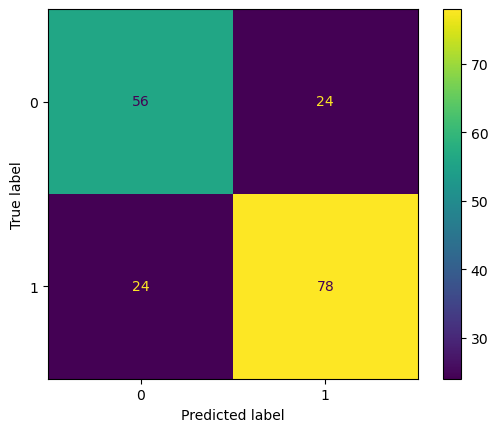

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.show()

In [28]:
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
importances = best_model.named_steps['classifier'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(10)

,Feature,Importance
7,cat__cp_asymptomatic,0.448339
2,num__chol,0.168246
4,num__oldpeak,0.081275
17,cat__exang_False,0.074705
24,cat__thal_normal,0.071917
0,num__age,0.060979
6,cat__sex_Male,0.025762
3,num__thalch,0.022128
1,num__trestbps,0.016978
22,cat__slope_upsloping,0.013743


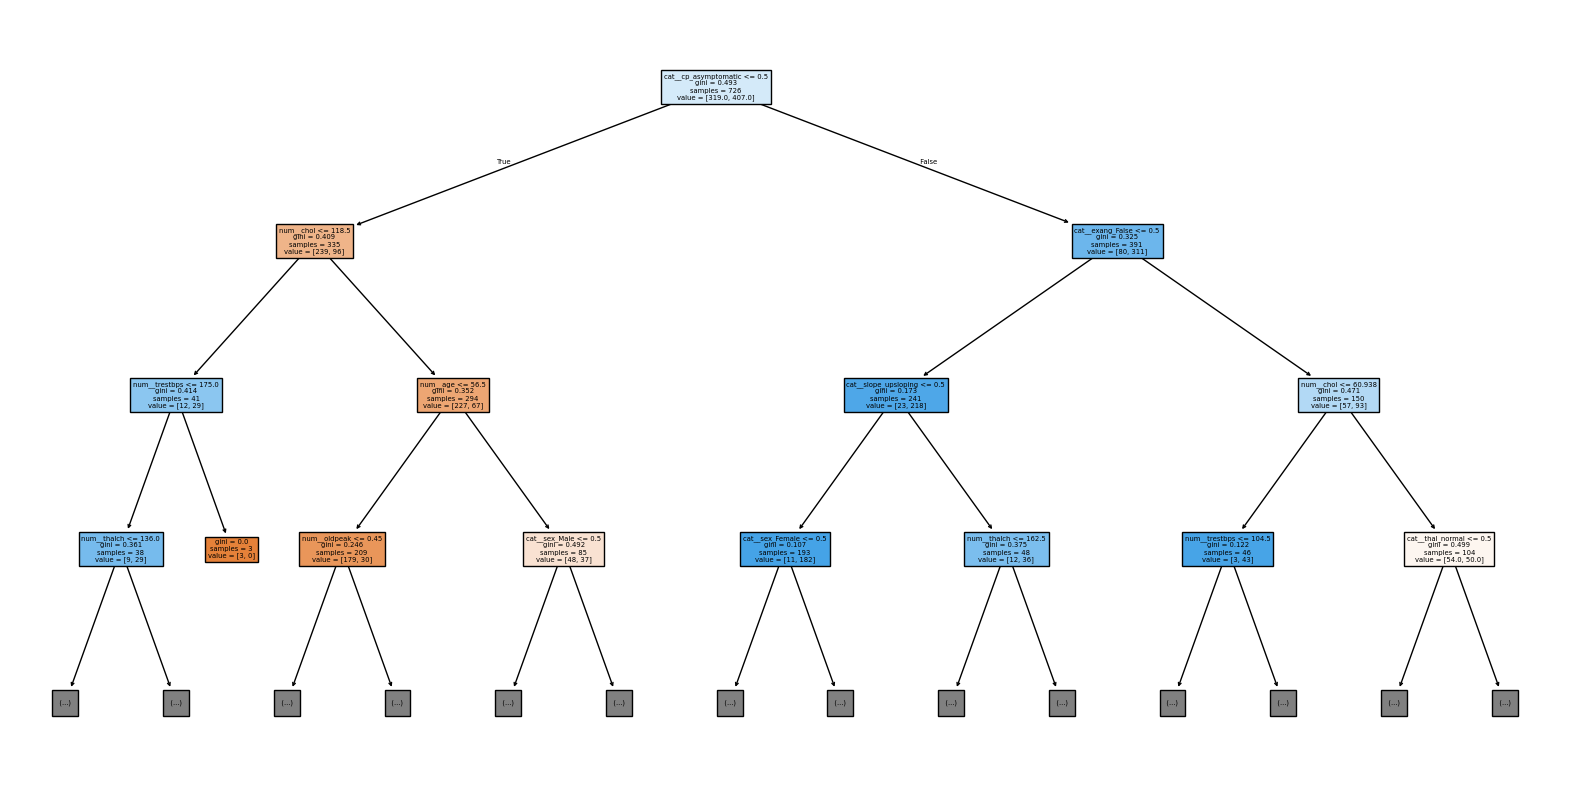

In [29]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(
    best_model.named_steps['classifier'],
    feature_names=feature_names,
    filled=True,
    max_depth=3
)
plt.show()

In [33]:
print("""After preprocessing (missing value imputation, outlier treatment, and encoding), a Decision Tree classifier was trained on the heart disease dataset. Hyperparameter tuning was performed using GridSearchCV with accuracy as the optimization metric.
Final Tuned Model Performance
Accuracy: 78.57%
Balanced precision and recall
Improved generalization compared to the baseline model
This indicates that the model can correctly classify nearly 4 out of 5 patients, which is a strong result for a single decision tree on medical data.

Class 1 (Heart Disease – Positive Class)
High recall: The model successfully identifies most patients with heart disease.
Good precision: Predictions of heart disease are reliable.

The Decision Tree model provides built-in feature importance, which helps interpret how decisions are made.

Top Important Features Identified
Chest pain type (asymptomatic) - Highest - Strong indicator of heart disease
Cholesterol (chol) - High - Elevated levels increase risk
ST depression (oldpeak) - Moderate - Indicates cardiac stress
Exercise-induced angina (exang) - Moderate - Important clinical signal
Thalassemia (thal) - Moderate - Normal values reduce risk
Age - Lower - Risk increases with age
Sex (Male) - Lower - Males show higher prevalence

Interpreting Decision Tree
Root node: Represents the most important feature (often chest pain type).
Splits: Each node applies a condition (e.g., oldpeak <= 1.8).
Branches: Show decision paths taken based on feature values.
Leaf nodes: Represent final predictions (heart disease or not).

Key Observations from the Tree
The model prioritizes chest pain characteristics and clinical test results
Simple, interpretable decision rules are learned
Confirms alignment with real-world medical knowledge

The Decision Tree classifier performed well after tuning, achieving 78.6% accuracy. Feature importance and tree visualization show that the model relies primarily on clinically meaningful features. The model is interpretable, making it suitable for decision-support applications in healthcare, although ensemble methods could further improve performance.
""")

After preprocessing (missing value imputation, outlier treatment, and encoding), a Decision Tree classifier was trained on the heart disease dataset. Hyperparameter tuning was performed using GridSearchCV with accuracy as the optimization metric.
Final Tuned Model Performance
Accuracy: 78.57%
Balanced precision and recall
Improved generalization compared to the baseline model
This indicates that the model can correctly classify nearly 4 out of 5 patients, which is a strong result for a single decision tree on medical data.

Class 1 (Heart Disease – Positive Class)
High recall: The model successfully identifies most patients with heart disease.
Good precision: Predictions of heart disease are reliable.

The Decision Tree model provides built-in feature importance, which helps interpret how decisions are made.

Top Important Features Identified
Chest pain type (asymptomatic) - Highest - Strong indicator of heart disease
Cholesterol (chol) - High - Elevated levels increase risk
ST depress

In [35]:
print("""Interview Questions
1. What are some common hyperparameters of decision tree models, and how do they affect performance?
Answer:
Hyperparameter	Effect
max_depth	Limits tree depth; controls overfitting
min_samples_split	Minimum samples needed to split a node
min_samples_leaf	Minimum samples in a leaf; smooths predictions
criterion	Metric to measure split quality (gini, entropy)
max_features	Number of features considered at each split
--Proper tuning balances the bias–variance trade-off.

2. What is the difference between Label Encoding and One-Hot Encoding?
Aspect	Label Encoding	One-Hot Encoding
Output	Integer labels	Binary vectors
Order assumption	Implies order	No order assumed
Best for	Tree models (sometimes)	Linear & distance-based models
Example	Red=0, Blue=1	Red=[1,0], Blue=[0,1]
--One-Hot Encoding is preferred for nominal categorical data to avoid misleading ordinal relationships.""")

Interview Questions
1. What are some common hyperparameters of decision tree models, and how do they affect performance?
Answer:
Hyperparameter	Effect
max_depth	Limits tree depth; controls overfitting
min_samples_split	Minimum samples needed to split a node
min_samples_leaf	Minimum samples in a leaf; smooths predictions
criterion	Metric to measure split quality (gini, entropy)
max_features	Number of features considered at each split
--Proper tuning balances the bias–variance trade-off.

2. What is the difference between Label Encoding and One-Hot Encoding?
Aspect	Label Encoding	One-Hot Encoding
Output	Integer labels	Binary vectors
Order assumption	Implies order	No order assumed
Best for	Tree models (sometimes)	Linear & distance-based models
Example	Red=0, Blue=1	Red=[1,0], Blue=[0,1]
--One-Hot Encoding is preferred for nominal categorical data to avoid misleading ordinal relationships.
